In [1]:
print('hiy')

hiy


In [1]:
# Create autoencoders with different encoded_dim values
from dim_reduction.autoencoder import Autoencoder

# Create autoencoders with different encoded_dim values
autoencoder_4 = Autoencoder(encoded_dim=4)
autoencoder_8 = Autoencoder(encoded_dim=8)
autoencoder_16 = Autoencoder(encoded_dim=16)
autoencoder_32 = Autoencoder(encoded_dim=32)
autoencoder_64 = Autoencoder(encoded_dim=64)


In [2]:
# Get some
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import gdown

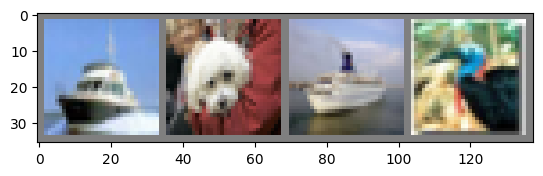

In [3]:
# Get some
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Define a transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the CIFAR-10 training dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

# Function to show an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = dataiter.__next__()

# Show images
imshow(torchvision.utils.make_grid(images))

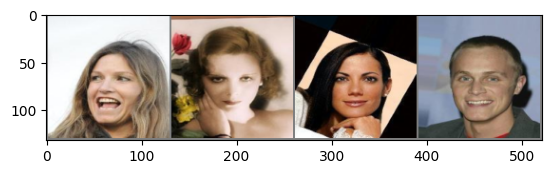

In [7]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Define a transform to resize and normalize the data
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the CelebA training dataset
trainset = torchvision.datasets.CelebA(root='./data', split='train', download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

# Function to show an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)  # Use the built-in next() function

# Show images
imshow(torchvision.utils.make_grid(images))

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001DD98F01F30>
Traceback (most recent call last):
  File "c:\projects\the-ai-jungle\the-ai-jungle\dim_reduction\.venv\lib\site-packages\torch\utils\data\dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "c:\projects\the-ai-jungle\the-ai-jungle\dim_reduction\.venv\lib\site-packages\torch\utils\data\dataloader.py", line 1582, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "C:\Users\User\.pyenv\pyenv-win\versions\3.10.0\lib\multiprocessing\process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "C:\Users\User\.pyenv\pyenv-win\versions\3.10.0\lib\multiprocessing\popen_spawn_win32.py", line 108, in wait
    res = _winapi.WaitForSingleObject(int(self._handle), msecs)
KeyboardInterrupt: 


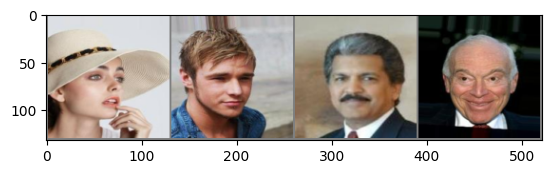

Training autoencoder with encoded_dim=4


In [ ]:
import os
import gdown
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
import torch.nn as nn
from dim_reduction.autoencoder import Autoencoder

# Define a transform to resize and normalize the data
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download the CelebA dataset using gdown
#url = 'https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS'
#output = './data/celeba.zip'
#gdown.download(url, output, quiet=False)
#
## Unzip the dataset
#import zipfile
#with zipfile.ZipFile(output, 'r') as zip_ref:
#    zip_ref.extractall('./data/celeba')

# Load the CelebA training dataset
trainset = torchvision.datasets.ImageFolder(root='./data/celeba', transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

# Function to show an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)  # Use the built-in next() function

# Show images
imshow(torchvision.utils.make_grid(images))

# Define a training function
def train_autoencoder(autoencoder, trainloader, epochs=5):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, _ = data
            inputs = inputs.to(device)
            
            optimizer.zero_grad()
            
            outputs = autoencoder(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            if i % 1000 == 999:  # print every 1000 mini-batches
                print(f"[{epoch + 1}, {i + 1}] loss: {running_loss / 1000:.3f}")
                running_loss = 0.0

    print("Finished Training")

# Train autoencoders with different encoded_dim values
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

autoencoders = [
    Autoencoder(encoded_dim=4).to(device),
    Autoencoder(encoded_dim=8).to(device),
    Autoencoder(encoded_dim=16).to(device),
    Autoencoder(encoded_dim=32).to(device),
    Autoencoder(encoded_dim=64).to(device)
]

for autoencoder in autoencoders:
    print(f"Training autoencoder with encoded_dim={autoencoder.encoder[-1].out_features}")
    train_autoencoder(autoencoder, trainloader)

In [2]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, encoded_dim=16):  # 👈 Check this parameter
        super(Autoencoder, self).__init__()

        # Encoder: Compresses image
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, encoded_dim)  # 👈 Compression happens here
        )

        # Decoder: Reconstructs image
        self.decoder = nn.Sequential(
            nn.Linear(encoded_dim, 32 * 8 * 8),  # 👈 Expands back to image size
            nn.ReLU(),
            nn.Unflatten(1, (32, 8, 8)),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Ensure output is in [0,1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [25]:
# download the dataset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define dataset transformation
transform = transforms.Compose([
    transforms.ToTensor()  # Convert to tensor (already 32x32)
])

# Load CIFAR-10 dataset
dataset = datasets.CIFAR10(root="data", train=True, transform=transform, download=True)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)




In [26]:
# train the autoencoder
import torch.optim as optim

# Define optimizer and loss function
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder.to(device)

# Training loop
num_epochs = 2
for epoch in range(num_epochs):
    for images, _ in train_loader:
        images = images.to(device)

        # Forward pass
        outputs = autoencoder(images)
        loss = criterion(outputs, images)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("Training completed!")


Epoch [1/2], Loss: 0.0049
Epoch [2/2], Loss: 0.0038
Training completed!


In [35]:
import os
import tempfile
import torch
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, structural_similarity as ssim
from torch.utils.data import DataLoader

def calculate_size_in_kb(image_tensor, suffix=".jpg"):
    """Calculates the size of a tensor when saved as an image file."""
    img = image_tensor.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())  # Normalize to [0,1]
    
    with tempfile.NamedTemporaryFile(suffix=suffix, delete=False) as tmp:
        plt.imsave(tmp.name, img, format="jpeg")
        size_kb = os.path.getsize(tmp.name) / 1024
    os.remove(tmp.name)
    return size_kb

def calculate_encoded_size_in_kb(encoded_tensor):
    """Calculates the size of the encoded representation in KB."""
    with tempfile.NamedTemporaryFile(suffix=".bin", delete=False) as tmp:
        encoded_tensor.numpy().tofile(tmp.name)
        size_kb = os.path.getsize(tmp.name) / 1024
    os.remove(tmp.name)
    return size_kb

def calculate_mse(original, reconstructed):
    """Calculates the Mean Squared Error between the original and reconstructed images."""
    original_np = original.permute(1, 2, 0).numpy()
    reconstructed_np = reconstructed.permute(1, 2, 0).numpy()
    return mean_squared_error(original_np, reconstructed_np)

def calculate_ssim(original, reconstructed):
    """Calculates the Structural Similarity Index between the original and reconstructed images."""
    original_np = original.permute(1, 2, 0).numpy()
    reconstructed_np = reconstructed.permute(1, 2, 0).numpy()
    return ssim(original_np, reconstructed_np, multichannel=True)

def display_images_with_size_and_quality(image_dict):
    """Displays original and reconstructed images with their file sizes and quality metrics."""
    num_images = len(image_dict["original"])
    fig, axes = plt.subplots(2, num_images, figsize=(15, 4))
    
    for i in range(num_images):
        original = image_dict["original"][i]
        reconstructed = image_dict["reconstructed"][i]
        
        original_size = calculate_size_in_kb(original)
        reconstructed_size = calculate_size_in_kb(reconstructed)
        mse = calculate_mse(original, reconstructed)
        ssim_value = calculate_ssim(original, reconstructed)
        
        axes[0, i].imshow(original.permute(1, 2, 0).numpy())
        axes[1, i].imshow(reconstructed.permute(1, 2, 0).numpy())
        
        axes[0, i].axis("off")
        axes[1, i].axis("off")
        
        axes[0, i].set_title(f"Original\n{original_size:.2f} KB")
        axes[1, i].set_title(f"Reconstructed\n{reconstructed_size:.2f} KB\nMSE: {mse:.2f}\nSSIM: {ssim_value:.2f}")
    
    plt.show()

# Get a batch of test images
test_loader = DataLoader(dataset, batch_size=8, shuffle=True)
images, _ = next(iter(test_loader))
images = images.to(device)

# Encode and decode
with torch.no_grad():
    encoded = autoencoder.encoder(images)
    reconstructed = autoencoder.decoder(encoded)

# Move to CPU for visualization
images = images.cpu()
encoded = encoded.cpu()
reconstructed = reconstructed.cpu()

# Calculate sizes
original_size = calculate_size_in_kb(images[0])
encoded_size = calculate_encoded_size_in_kb(encoded[0])
reconstructed_size = calculate_size_in_kb(reconstructed[0])

print(f"Original image size: {original_size:.2f} KB")
print(f"Encoded representation size: {encoded_size:.2f} KB")
print(f"Reconstructed image size: {reconstructed_size:.2f} KB")

# Store images in a dictionary
image_dict = {
    "original": [images[i] for i in range(8)],
    "reconstructed": [reconstructed[i] for i in range(8)]
}

# Display images, sizes, and quality metrics
display_images_with_size_and_quality(image_dict)

ModuleNotFoundError: No module named 'skimage'

In [19]:
# save the model
torch.save(autoencoder.state_dict(), "model/autoencoder.pth")

In [20]:
# load the model
autoencoder.load_state_dict(torch.load("model/autoencoder.pth"))
autoencoder.eval()

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)